In [1]:
"""
Things I learnt through this project:
1. Linear Regression with one variable
2. Data Preprocessing
3. Data Visualizations
4. Handling Data using Pandas library
5. Learnt how to implement cost function and gradient descent by your own without learning sklearn or other such library.
6. Finally got a staright line
"""

'\nThings I learnt through this project:\n1. Linear Regression with one variable\n2. Data Preprocessing\n3. Data Visualizations\n4. Handling Data using Pandas library\n5. Learnt how to implement cost function and gradient descent by your own without learning sklearn or other such library.\n6. Finally got a staright line\n'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score
from sklearn.linear_model import LinearRegression

In [3]:
print("hello")

hello


In [4]:
df=pd.read_csv("HousingData.csv")
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [5]:
print(df.isnull().values.any())
df.isnull().sum()
#RM and MEDV values are not null so right now for simplicity we will only consider RM and MEDV.

True


CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

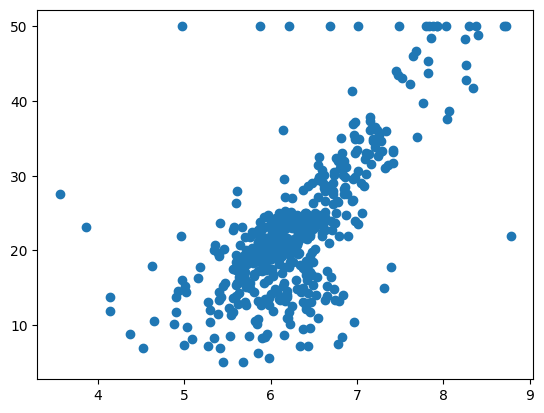

In [6]:
plt.scatter(df["RM"],df["MEDV"])
plt.show()

In [7]:
"""
RM= Total number of rooms in the dwelling
MEDV= Median value of house in dollars($).
Now we will plot a regression line for predicting MEDV for given RM's.
"""
x=df["RM"].to_numpy()
y=df["MEDV"].to_numpy()
print("X shape: ",x.shape)
print("Y shape: ",y.shape)

X shape:  (506,)
Y shape:  (506,)


In [8]:
def compute_cost(x,y,w,b):
    m=x.shape[0]
    cost_sum=0
    for i in range(m):
        line_pt=w*x[i]+b
        cost=(line_pt-y[i])**2
        cost_sum+=cost
    total_sum=(1/(2*m))*cost_sum
    return total_sum

In [9]:
def compute_gradient_descent(x,y,w,b):
    m=x.shape[0]
    init_weight=0
    init_bias=0
    for i in range(m):
        line_pt=w*x[i]+b
        init_weight_val=(line_pt-y[i])*x[i]
        init_bias_val=(line_pt-y[i])
        init_weight+=init_weight_val
        init_bias+=init_bias_val
    init_weight=init_weight/m
    init_bias=init_bias/m
    return init_weight,init_bias
    

In [10]:

def gradient_descent(x,y,w,b,alpha,epochs,cost_history):
    for i in range(epochs):
        wg,bg=compute_gradient_descent(x,y,w,b)
        w=w-(alpha*wg)
        b=b-(alpha*bg)
        cost_history.append(compute_cost(x,y,w,b))
    return w,b,cost_history


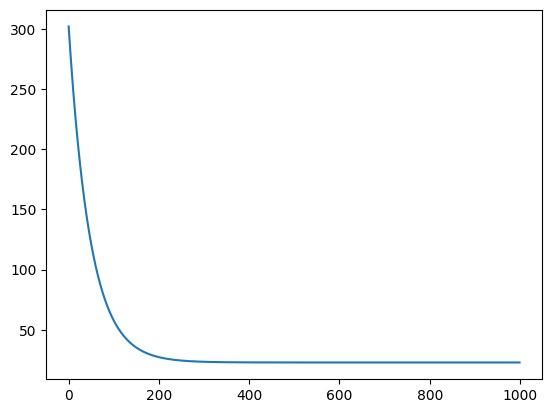

In [11]:
weight=0
bias=0
alpha=0.01
epochs=1000
cost_history=[]
mean=x.mean()
std=x.std()
x=(x-mean)/std
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)
fw,fb,cost_history=gradient_descent(x_train,y_train,weight,bias,alpha=alpha,epochs=epochs,cost_history=cost_history)
plt.plot(cost_history)

6.345023598861035 22.58392114469603


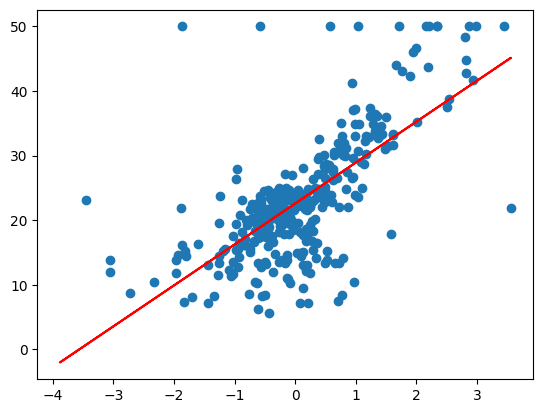

In [12]:
print(fw,fb)
plt.scatter(x_train,y_train)
plt.plot(x,fw*x+fb,color="red")

In [13]:
def predict(x,w,b):
    return w*x+b

In [14]:
y_res=predict(x_test,fw,fb)

In [15]:
print("mean_squared_error: ",mean_squared_error(y_test,y_res))
print("R2 score: ",r2_score(y_test,y_res))

mean_squared_error:  39.09065859874987
R2 score:  0.48346420351796093


In [16]:
model=LinearRegression()
x_train=x_train.reshape(-1,1)
model.fit(x_train,y_train)

LinearRegression()

In [17]:
y_pred=model.predict(x_test.reshape(-1,1))

In [18]:
print("Mean sqaured error in case of scikit-learn implementation: ",mean_squared_error(y_test,y_pred))
print("R2_score in case of scikit-learn implementation: ",r2_score(y_test,y_pred))

Mean sqaured error in case of scikit-learn implementation:  39.09105111486995
R2_score in case of scikit-learn implementation:  0.4834590168919488
